In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [42]:
df = pd.read_csv("Titanic-Dataset.csv",usecols=["Age","Fare","Survived"])
df["Age"].isnull().sum()

np.int64(177)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].mode())
df["Age"].head(15)
df["Fare"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Name: Fare, Length: 891, dtype: bool

In [5]:
X = df.iloc[:,1:3]
Y = df.iloc[:,0]

In [6]:
#  Train Test Split
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X,Y,test_size=0.2,random_state=42)

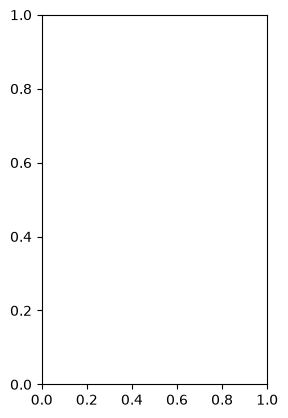

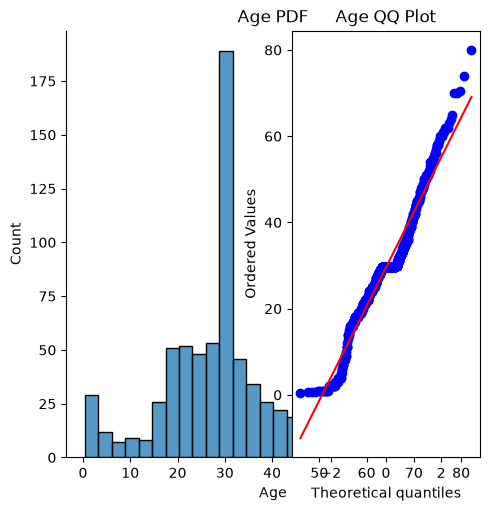

In [55]:
#  PDF plot and QQ Plot : Age
plt.Figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_Train["Age"])
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_Train["Age"],dist="norm",plot=plt)
plt.title("Age QQ Plot")

plt.show()

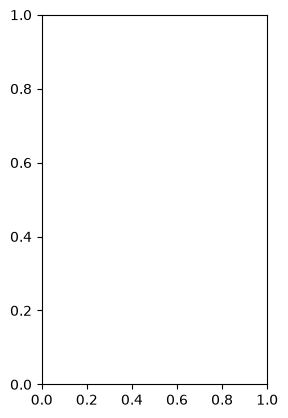

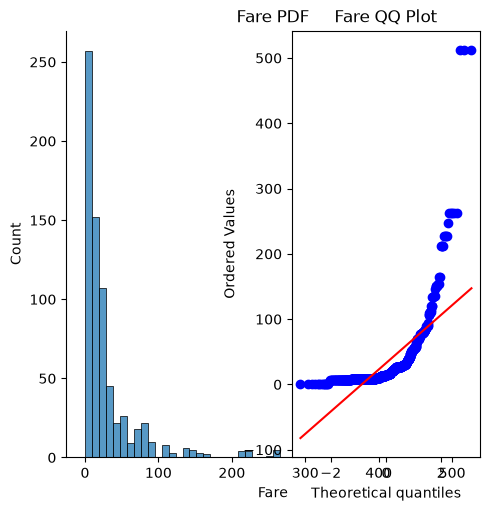

In [54]:
#  PDF plot and QQ Plot : Fare
plt.Figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_Train["Fare"])
plt.title("Fare PDF")

plt.subplot(122)
stats.probplot(X_Train["Fare"],dist="norm",plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [9]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_Train,Y_Train)
clf2.fit(X_Train,Y_Train)

Y_pred1 = clf1.predict(X_Test)
Y_pred2 = clf2.predict(X_Test)

print("Accuracy LR : ",accuracy_score(Y_pred1,Y_Test))
print("Accuracy Decision Tree : ",accuracy_score(Y_pred2,Y_Test))

Accuracy LR :  0.6480446927374302
Accuracy Decision Tree :  0.6703910614525139


In [10]:
trf = FunctionTransformer(func=np.log1p)

In [11]:
X_train_Transformed = trf.fit_transform(X_Train)
X_test_Transformed = trf.fit_transform(X_Test)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_Transformed,Y_Train)
clf2.fit(X_train_Transformed,Y_Train)

y_pred1 = clf1.predict(X_test_Transformed)
y_pred2 = clf2.predict(X_test_Transformed)

print("Accuracy LR : ",accuracy_score(Y_Test,y_pred1))
print("Accuracy Decision Tree : ",accuracy_score(Y_Test,y_pred1))

Accuracy LR :  0.6815642458100558
Accuracy Decision Tree :  0.6815642458100558


In [12]:
X_transformed = trf.fit_transform(X)

In [13]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR : ",np.mean(cross_val_score(clf,X_transformed,Y,scoring='accuracy',cv=10)))
print("Decision Tree : ",np.mean(cross_val_score(clf2,X_transformed,Y,scoring='accuracy',cv=10)))

LR :  0.678027465667915
Decision Tree :  0.6566167290886392


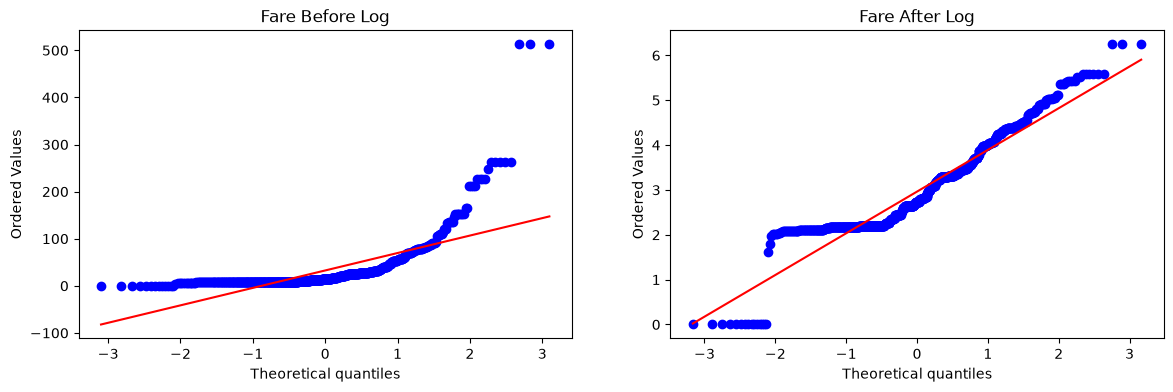

In [14]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_Train["Fare"],dist="norm",plot=plt)
plt.title("Fare Before Log")

plt.subplot(122)
stats.probplot(X_transformed["Fare"],dist="norm",plot=plt)
plt.title("Fare After Log")

plt.show()

In [57]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

x_train_transformed2 = trf2.fit_transform(X_Train)
X_test_transformed2 = trf2.fit_transform(X_Test)

clf = DecisionTreeClassifier()
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_transformed2,Y_Train)
clf2.fit(x_train_transformed2,Y_Train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf.predict(X_test_transformed2)

print("LR accuracy score : ",accuracy_score(Y_Test,y_pred))

print("Decision Tree accuracy score : ",accuracy_score(Y_Test,y_pred2))

LR accuracy score :  0.6703910614525139
Decision Tree accuracy score :  0.6703910614525139


In [58]:
X_transformed = trf.fit_transform(x_train_transformed2)

In [59]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR : ",np.mean(cross_val_score(clf,X_transformed,Y_Train,scoring='accuracy',cv=10)))
print("Decision Tree : ",np.mean(cross_val_score(clf2,X_transformed,Y_Train,scoring='accuracy',cv=10)))

LR :  0.675508607198748
Decision Tree :  0.6249608763693272
